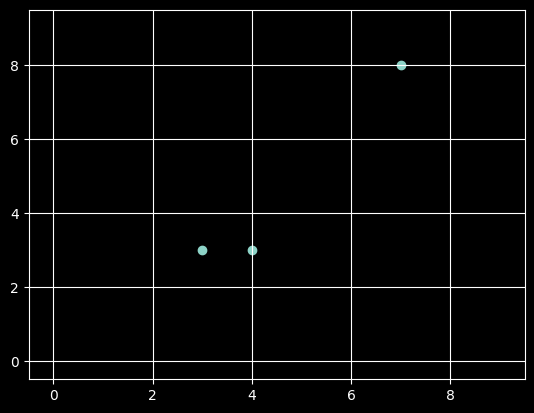

In [13]:
import math

from mesa import Model, Agent
from mesa.space import MultiGrid
import matplotlib.pyplot as plt

class Person(Agent):
    def __init__(self, uid, model):
        super().__init__(uid, model)

class City(Model):
    def __init__(self):
        super().__init__()
        self.grid = MultiGrid(10, 10, torus=False)


        self.persons = [Person(1, self), Person(2, self), Person(3, self)]

        for agent, pos in zip(self.persons, [(3, 3), (4, 3), (7, 8)]):
            self.grid.place_agent(agent, pos)

    def show(self):
        xs = [a.pos[0] for a in self.persons]
        ys = [a.pos[1] for a in self.persons]

        plt.grid()
        plt.scatter(xs, ys)
        plt.xlim(-0.5, 9.5)
        plt.ylim(-0.5, 9.5)
        plt.show()

model = City()
model.show()

print(list(model.grid.iter_neighbors((3, 3), moore=True)))

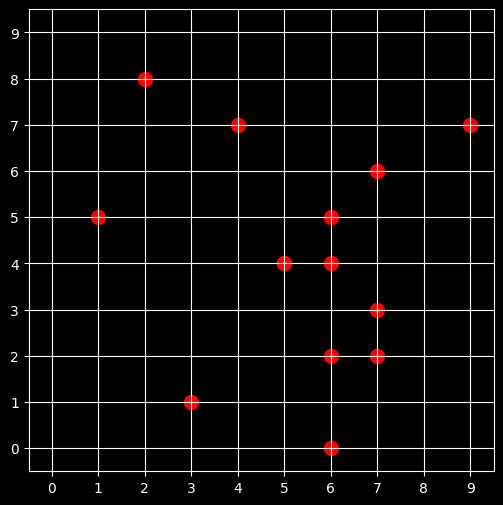

Agent 0 staat op (9, 7) en heeft kleur red
Agent 1 staat op (6, 2) en heeft kleur red
Agent 2 staat op (6, 0) en heeft kleur red
Agent 3 staat op (1, 5) en heeft kleur red
Agent 4 staat op (4, 7) en heeft kleur red
Agent 5 staat op (7, 6) en heeft kleur red
Agent 6 staat op (7, 2) en heeft kleur red
Agent 7 staat op (7, 3) en heeft kleur red
Agent 8 staat op (5, 4) en heeft kleur red
Agent 9 staat op (5, 4) en heeft kleur red
Agent 10 staat op (3, 1) en heeft kleur red
Agent 11 staat op (6, 5) en heeft kleur red
Agent 12 staat op (6, 4) en heeft kleur red
Agent 13 staat op (2, 8) en heeft kleur red


In [2]:
from mesa import Model, Agent
from mesa.space import MultiGrid
import matplotlib.pyplot as plt
import random


class Person(Agent):
    def __init__(self, uid, model, color):
        super().__init__(uid, model)
        self.color = color


class City(Model):
    def __init__(self, width=10, height=10, num_agents=None):
        super().__init__()
        self.grid = MultiGrid(width, height, torus=False)

        # dit zorgt ervoor dat een random aantal agenten op het grid terecht komt.
        if num_agents is None:
            num_agents = random.randint(5, 15)

        self.persons = []
# alle agenten (dus husihoudens) krijgen een rode kleur op het grid
        possible_colors = ["red"]

        for i in range(num_agents):
            color = random.choice(possible_colors)
            person = Person(i, self, color)

            x = random.randint(0, width - 1)
            y = random.randint(0, height - 1)

            self.grid.place_agent(person, (x, y))
            self.persons.append(person)

    def show(self):
        plt.figure(figsize=(6, 6))

        for person in self.persons:
            x, y = person.pos
            plt.scatter(x, y, color=person.color, s=100)

        plt.xlim(-0.5, self.grid.width - 0.5)
        plt.ylim(-0.5, self.grid.height - 0.5)
        plt.xticks(range(self.grid.width))
        plt.yticks(range(self.grid.height))
        plt.grid(True)
        plt.show()


model = City()
model.show()

for person in model.persons:
    print(f"Agent {person.unique_id} staat op {person.pos} en heeft kleur {person.color}")

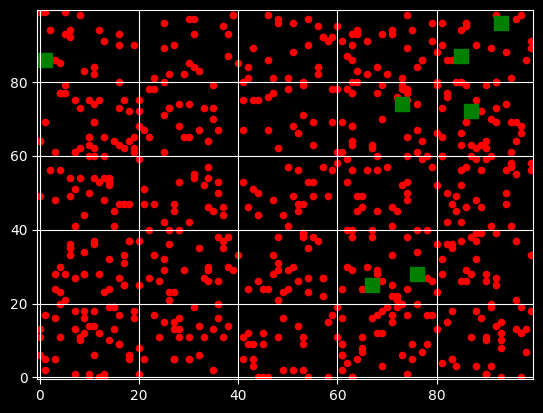

In [19]:
from mesa import Model, Agent
from mesa.space import MultiGrid
import matplotlib.pyplot as plt
import random
import math

#dit is de eerste agent, de huishoudens. nu staan er nog geen variabelen in, maar dat is wat we later wel gaan toevoegen.
class Huishouden(Agent):
    def __init__(self, id, model):
        super().__init__(id, model)

#dit is de tweede agent, de containers. hier komen later ook nog meer karakteristieken bij
class Container(Agent):
    def __init__(self, id, model):
        super().__init__(id, model)

#hierbinnen gaan wij simuleren, deze karakteristieken moeten ook aangepast worden
class Stad(Model):
    def __init__(self, width=10, height=10, num_people=100, people_per_container=250):
        #width is de breedte, height de hoogte, num people aantal personen in de stad, people per container is de variabele die wij nog moeten beargumenteren
        super().__init__()

        self.grid = MultiGrid(width, height, torus=False)
        #multi grid houdt in dat er meerdere agents op een plek kunnen syaan, we moeten nadenken of dit wel kan met een huis? ik denk van wel omdat elk vakje een paar km is
        #door de torus stoppen we bij de rand en gaat helemaal rechts niet door links etc

        #lijst met alle huishoudens
        self.huishoudens = []
        #lijst met alle containers
        self.containers = []
        #telt alle unieke ids
        self.id = 0

        #deze formule bereknt het aantal containers aan de hand van de personen. de aantal containers worden altijd afgerond naar boven toe
        num_containers = math.ceil(num_people / people_per_container)

        #plaats de containers die berekend zijn in het grid
        for _ in range(num_containers):
            c = Container(self.next_id(), self)
            #dit geeft elke container een unieke plaats binnen de stad
            self.grid.place_agent(c, (random.randint(0, width-1), random.randint(0, height-1)))
            #voeg hem toe aan de lijst van de containers
            self.containers.append(c)

       #plaats de huishoudens in het grid/stad
        for _ in range(num_people):
            h = Huishouden(self.next_id(), self)
            self.grid.place_agent(h, (random.randint(0, width-1), random.randint(0, height-1)))
            self.huishoudens.append(h)

    #elke keer als er een agent gemaakt word gaat het id met 1 omhoog, zo voorkom je dat agents dezelfde id krijgen
    def next_id(self):
        self.id += 1
        return self.id

    def show(self):
        for p in self.huishoudens:
            plt.scatter(p.pos[0], p.pos[1], color="red", s=20)

        for c in self.containers:
            plt.scatter(c.pos[0], c.pos[1], color="green", s=100, marker="s")

        plt.grid()
        plt.xlim(-0.5, self.grid.width - 0.5)
        plt.ylim(-0.5, self.grid.height - 0.5)
        plt.show()


model = Stad(width=100, height=100, num_people=650, people_per_container=100)
model.show()

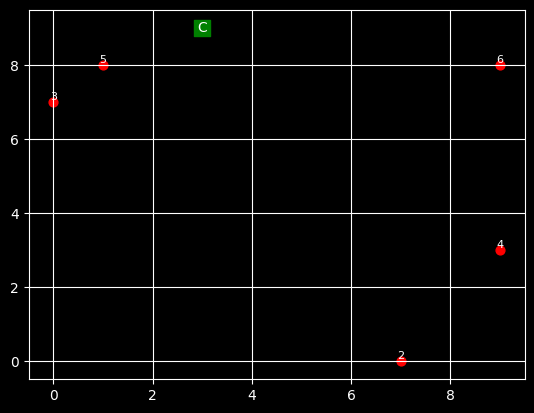

Container staat op positie: (3, 9)

Huishouden 2 staat op (7, 0) --> afstand = 9.85
Huishouden 3 staat op (0, 7) --> afstand = 3.61
Huishouden 4 staat op (9, 3) --> afstand = 8.49
Huishouden 5 staat op (1, 8) --> afstand = 2.24
Huishouden 6 staat op (9, 8) --> afstand = 6.08


In [21]:
from mesa import Model, Agent
from mesa.space import MultiGrid
import matplotlib.pyplot as plt
import random
import math


# Dit is de eerste agent: huishoudens
class Huishouden(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)


# Dit is de tweede agent: containers
class Container(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)


# Hierin simuleren we de stad
class Stad(Model):
    def __init__(self, width=10, height=10, num_people=5, people_per_container=10):
        super().__init__()

        # Grid waarin meerdere agents op dezelfde plek kunnen staan
        self.grid = MultiGrid(width, height, torus=False)

        # Lijsten voor huishoudens en containers
        self.huishoudens = []
        self.containers = []

        # Teller voor unieke ids
        self.id = 0

        # Bereken aantal containers
        num_containers = math.ceil(num_people / people_per_container)

        # Plaats de containers in het grid
        for _ in range(num_containers):
            c = Container(self.next_id(), self)
            self.grid.place_agent(c, (random.randint(0, width - 1), random.randint(0, height - 1)))
            self.containers.append(c)

        # Plaats de huishoudens in het grid
        for _ in range(num_people):
            h = Huishouden(self.next_id(), self)
            self.grid.place_agent(h, (random.randint(0, width - 1), random.randint(0, height - 1)))
            self.huishoudens.append(h)

    # Geeft elke agent een uniek id
    def next_id(self):
        self.id += 1
        return self.id

    # Bereken de Euclidische afstand tussen twee posities
    def euclidische_afstand(self, pos1, pos2):
        return math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

    # Toon voor elk huishouden de afstand tot de container
    def toon_afstanden(self):
        container = self.containers[0]

        print(f"Container staat op positie: {container.pos}\n")

        for huishouden in self.huishoudens:
            afstand = self.euclidische_afstand(huishouden.pos, container.pos)
            print(f"Huishouden {huishouden.unique_id} staat op {huishouden.pos} --> afstand = {afstand:.2f}")

    # Laat het grid zien
    def show(self):
        for h in self.huishoudens:
            x, y = h.pos

            # Teken huishouden
            plt.scatter(x, y, color="red", s=40)

            # Label met unique_id
            plt.text(x, y, str(h.unique_id), fontsize=8, ha="center", va="bottom")

        for c in self.containers:
            x, y = c.pos

            # Teken container
            plt.scatter(x, y, color="green", s=120, marker="s")

            # Label voor container
            plt.text(x, y, "C", fontsize=10, ha="center", va="center", color="white")

        plt.grid()
        plt.xlim(-0.5, self.grid.width - 0.5)
        plt.ylim(-0.5, self.grid.height - 0.5)
        plt.show()


# Model maken en tonen
model = Stad(width=10, height=10, num_people=5, people_per_container=10)
model.show()
model.toon_afstanden()

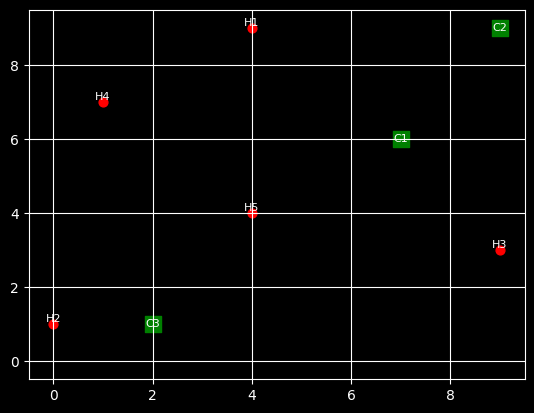

Containers:
Container 1 staat op positie (7, 6)
Container 2 staat op positie (9, 9)
Container 3 staat op positie (2, 1)

Huishoudens:
Huishouden 1 staat op (4, 9) --> gaat naar container 1 op (7, 6) --> afstand = 4.24
Huishouden 2 staat op (0, 1) --> gaat naar container 3 op (2, 1) --> afstand = 2.00
Huishouden 3 staat op (9, 3) --> gaat naar container 1 op (7, 6) --> afstand = 3.61
Huishouden 4 staat op (1, 7) --> gaat naar container 1 op (7, 6) --> afstand = 6.08
Huishouden 5 staat op (4, 4) --> gaat naar container 1 op (7, 6) --> afstand = 3.61


In [22]:
from mesa import Model, Agent
from mesa.space import MultiGrid
import matplotlib.pyplot as plt
import random
import math


# Agent: huishouden
class Huishouden(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)


# Agent: container
class Container(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)


# Model: stad
class Stad(Model):
    def __init__(self, width=10, height=10, num_people=5, people_per_container=2):
        super().__init__()

        self.grid = MultiGrid(width, height, torus=False)

        self.huishoudens = []
        self.containers = []

        self.id = 0

        # bereken aantal containers
        num_containers = math.ceil(num_people / people_per_container)

        # plaats containers
        for _ in range(num_containers):
            c = Container(self.next_id(), self)
            self.grid.place_agent(c, (random.randint(0, width - 1), random.randint(0, height - 1)))
            self.containers.append(c)

        # plaats huishoudens
        for _ in range(num_people):
            h = Huishouden(self.next_id(), self)
            self.grid.place_agent(h, (random.randint(0, width - 1), random.randint(0, height - 1)))
            self.huishoudens.append(h)

    # maak steeds een nieuw uniek id
    def next_id(self):
        self.id += 1
        return self.id

    # bereken euclidische afstand tussen twee posities
    def euclidische_afstand(self, pos1, pos2):
        return math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

    # zoek voor een huishouden welke container het dichtstbij is
    def dichtstbijzijnde_container(self, huishouden):
        beste_container = None
        kleinste_afstand = float("inf")


        for container in self.containers:
            afstand = self.euclidische_afstand(huishouden.pos, container.pos)

            #dit omdat huishoudens altijd naar containers zullen lopen die het meest dichtbij zijn (aanname)
            if afstand < kleinste_afstand:
                kleinste_afstand = afstand
                beste_container = container

        return beste_container, kleinste_afstand

    # print per huishouden de dichtstbijzijnde container en de afstand
    def toon_resultaten(self):
        print("Containers:")
        for i, container in enumerate(self.containers, start=1):
            print(f"Container {i} staat op positie {container.pos}")

        print("\nHuishoudens:")
        for i, huishouden in enumerate(self.huishoudens, start=1):
            container, afstand = self.dichtstbijzijnde_container(huishouden)
            container_nummer = self.containers.index(container) + 1

            print(
                f"Huishouden {i} staat op {huishouden.pos} "
                f"--> gaat naar container {container_nummer} op {container.pos} "
                f"--> afstand = {afstand:.2f}"
            )

    # laat het grid zien
    def show(self):
        for i, h in enumerate(self.huishoudens, start=1):
            x, y = h.pos
            plt.scatter(x, y, color="red", s=40)
            plt.text(x, y, f"H{i}", fontsize=8, ha="center", va="bottom")

        for i, c in enumerate(self.containers, start=1):
            x, y = c.pos
            plt.scatter(x, y, color="green", s=120, marker="s")
            plt.text(x, y, f"C{i}", fontsize=8, ha="center", va="center", color="white")

        plt.grid()
        plt.xlim(-0.5, self.grid.width - 0.5)
        plt.ylim(-0.5, self.grid.height - 0.5)
        plt.show()


# model maken
model = Stad(width=10, height=10, num_people=5, people_per_container=2)
model.show()
model.toon_resultaten()

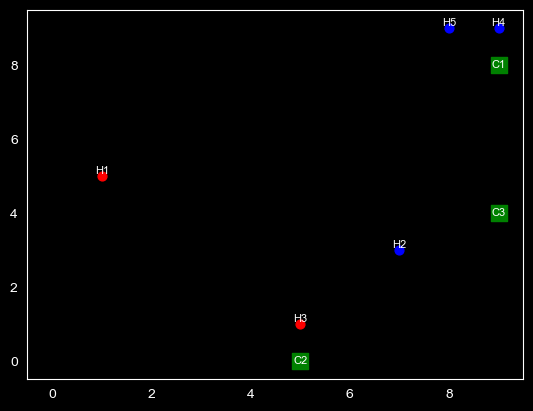


RESULTATEN:

Huishouden   Positie      Buren  Recyclewaarde    Recyclet  
------------------------------------------------------------
H1           (1, 5)       0      0.32             False     
H2           (7, 3)       0      0.57             True      
H3           (5, 1)       0      0.23             False     
H4           (9, 9)       1      0.66             True      
H5           (8, 9)       1      0.65             True      


In [1]:
# ik wil nu meenemen dat huishoudens buren kunnen hebben, voor het gemak rechts, links onder en boven. al deze buren geven een beinvloedingswaarde van +1. deze beinvloedingswaarde koppelt terug naar recyclegedrag. Ik denk dat recycle gedrag een random getal word tussen 0-1 en dat dan dus deze beinvloedingswaarde erbij komt. wanneer recycle gedrag boven een bepaald getal komt gaat een huishouden recycelen en anders niet. Voor nu neem ik aan dat elke buur zorgt voor +0.1 aan recyclegedarg erbij komt. dus 4 buren is +0.4


import random
import math
from mesa import Model, Agent
from mesa.space import MultiGrid
import matplotlib.pyplot as plt

# Agent: huishouden
class Huishouden(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)

        self.recyclewaarde = 0
        self.sociale_gevoeligheid = 0
        self.recyclet = False


# Agent: container
class Container(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)


# Model: stad
class Stad(Model):
    def __init__(self, width=10, height=10, num_people=5, people_per_container=2):
        super().__init__()

        self.grid = MultiGrid(width, height, torus=False)

        self.huishoudens = []
        self.containers = []

        self.id = 0

        # drempelwaarde
        self.drempel = 0.5

        # aantal containers berekenen
        num_containers = math.ceil(num_people / people_per_container)

        # containers plaatsen
        for _ in range(num_containers):
            c = Container(self.next_id(), self)
            self.grid.place_agent(c, (random.randint(0, width - 1), random.randint(0, height - 1)))
            self.containers.append(c)

        # huishoudens plaatsen
        for _ in range(num_people):
            h = Huishouden(self.next_id(), self)
            self.grid.place_agent(h, (random.randint(0, width - 1), random.randint(0, height - 1)))
            self.huishoudens.append(h)

        # recyclegedrag berekenen
        self.bereken_recyclegedrag()

    # uniek id
    def next_id(self):
        self.id += 1
        return self.id

    # afstand berekenen
    def euclidische_afstand(self, pos1, pos2):
        return math.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

    # dichtstbijzijnde container
    def dichtstbijzijnde_container(self, huishouden):
        beste_container = None
        kleinste_afstand = float("inf")

        for container in self.containers:
            afstand = self.euclidische_afstand(huishouden.pos, container.pos)

            if afstand < kleinste_afstand:
                kleinste_afstand = afstand
                beste_container = container

        return beste_container, kleinste_afstand

    # buren tellen (4 richtingen)
    def tel_buren(self, huishouden):
        x, y = huishouden.pos
        aantal_buren = 0

        buur_posities = [
            (x - 1, y),
            (x + 1, y),
            (x, y - 1),
            (x, y + 1)
        ]

        for bx, by in buur_posities:
            if 0 <= bx < self.grid.width and 0 <= by < self.grid.height:
                inhoud = self.grid.get_cell_list_contents([(bx, by)])

                for agent in inhoud:
                    if isinstance(agent, Huishouden):
                        aantal_buren += 1

        return aantal_buren

    # recyclegedrag bepalen
    def bereken_recyclegedrag(self):
        for huishouden in self.huishoudens:

            # random startwaarde
            huishouden.recyclewaarde = random.random()

            # buren tellen
            huishouden.sociale_gevoeligheid = self.tel_buren(huishouden)

            # +0.1 per buur
            huishouden.recyclewaarde += huishouden.sociale_gevoeligheid * 0.1

            # beslissing
            if huishouden.recyclewaarde > self.drempel:
                huishouden.recyclet = True
            else:
                huishouden.recyclet = False

    # nette tabel
    def toon_resultaten(self):
        print("\nRESULTATEN:\n")

        print(f"{'Huishouden':<12} {'Positie':<12} {'Buren':<6} {'Recyclewaarde':<16} {'Recyclet':<10}")
        print("-" * 60)

        for i, huishouden in enumerate(self.huishoudens, start=1):
            print(
                f"H{i:<11} "
                f"{str(huishouden.pos):<12} "
                f"{huishouden.sociale_gevoeligheid:<6} "
                f"{huishouden.recyclewaarde:<16.2f} "
                f"{str(huishouden.recyclet):<10}"
            )

    # visualisatie
    def show(self):
        for i, h in enumerate(self.huishoudens, start=1):
            x, y = h.pos

            if h.recyclet:
                kleur = "blue"
            else:
                kleur = "red"

            plt.scatter(x, y, color=kleur, s=40)
            plt.text(x, y, f"H{i}", fontsize=8, ha="center", va="bottom")

        for i, c in enumerate(self.containers, start=1):
            x, y = c.pos
            plt.scatter(x, y, color="green", s=120, marker="s")
            plt.text(x, y, f"C{i}", fontsize=8, ha="center", va="center", color="white")

        plt.grid()
        plt.xlim(-0.5, self.grid.width - 0.5)
        plt.ylim(-0.5, self.grid.height - 0.5)
        plt.show()


# model runnen
model = Stad(width=10, height=10, num_people=5, people_per_container=2)
model.show()
model.toon_resultaten()


#

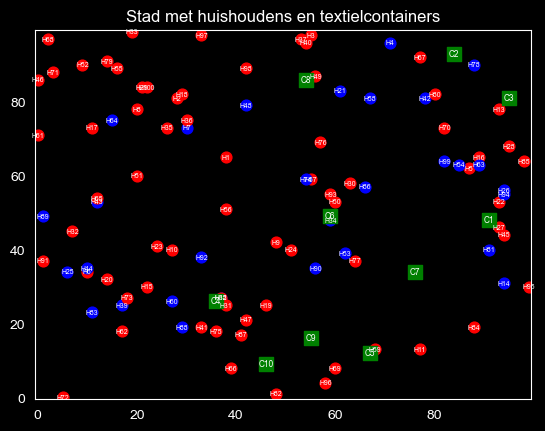


RESULTATEN:

Huishouden   Positie      Buren  Recyclewaarde    Recyclet  
------------------------------------------------------------
H1           (38, 65)     0      -0.13            False     
H2           (28, 81)     0      -0.19            False     
H3           (55, 98)     0      -0.06            False     
H4           (71, 96)     0      0.53             True      
H5           (87, 62)     0      0.48             False     
H6           (10, 34)     1      0.36             False     
H7           (30, 73)     0      0.59             True      
H8           (20, 78)     0      0.19             False     
H9           (48, 42)     0      -0.12            False     
H10          (27, 40)     0      -0.06            False     
H11          (77, 13)     0      0.49             False     
H12          (37, 27)     0      0.58             True      
H13          (93, 78)     0      0.43             False     
H14          (94, 31)     0      0.65             True      
H15       

In [48]:
## versie 1
# ik wil nu meenemen dat huishoudens buren kunnen hebben, voor het gemak rechts, links onder en boven. al deze buren geven een beinvloedingswaarde van +1. deze beinvloedingswaarde koppelt terug naar recyclegedrag. Ik denk dat recycle gedrag een random getal word tussen 0-1 en dat dan dus deze beinvloedingswaarde erbij komt. wanneer recycle gedrag boven een bepaald getal komt gaat een huishouden recycelen en anders niet. Voor nu neem ik aan dat elke buur zorgt voor +0.1 aan recyclegedarg erbij komt. dus 4 buren is +0.4


import random
import math
from mesa import Model, Agent
from mesa.space import MultiGrid
import matplotlib.pyplot as plt


# Agent: huishouden
class Huishouden(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)
        self.recyclewaarde = 0
        self.sociale_gevoeligheid = 0
        self.recyclegedrag = False


# Agent: container
class Container(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)

# Model: stad
class Stad(Model):
    def __init__(self, width=10, height=10, num_people=5, people_per_container=2):
        super().__init__()

        self.grid = MultiGrid(width, height, torus=False)

        self.huishoudens = []
        self.containers = []

        self.id = 0

        # drempelwaarde
        self.drempel = 0.5

        # aantal containers berekenen
        num_containers = math.ceil(num_people / people_per_container)

        # containers plaatsen
        for _ in range(num_containers):
            c = Container(self.next_id(), self)
            self.grid.place_agent(c, (random.randint(0, width - 1), random.randint(0, height - 1)))
            self.containers.append(c)

        # huishoudens plaatsen
        for _ in range(num_people):
            h = Huishouden(self.next_id(), self)
            self.grid.place_agent(h, (random.randint(0, width - 1), random.randint(0, height - 1)))
            self.huishoudens.append(h)

        # recyclegedrag berekenen
        self.bereken_recyclegedrag()

    def next_id(self):
        self.id += 1
        return self.id

    # afstand berekenen
    def euclidische_afstand(self, pos1, pos2):
        return math.sqrt((pos1[0] - pos2[0]) ** 2 + (pos1[1] - pos2[1]) ** 2)

    # dichtstbijzijnde container
    def dichtstbijzijnde_container(self, huishouden):
        beste_container = None
        kleinste_afstand = float("inf")

        for container in self.containers:
            afstand = self.euclidische_afstand(huishouden.pos, container.pos)

            if afstand < kleinste_afstand:
                kleinste_afstand = afstand
                beste_container = container

        return beste_container, kleinste_afstand

    # buren tellen (4 richtingen)
    def tel_buren(self, huishouden):
        x, y = huishouden.pos
        aantal_buren = 0

        buur_posities = [
            (x - 1, y),
            (x + 1, y),
            (x, y - 1),
            (x, y + 1)
        ]

        for bx, by in buur_posities:
            if 0 <= bx < self.grid.width and 0 <= by < self.grid.height:
                inhoud = self.grid.get_cell_list_contents([(bx, by)])

                for agent in inhoud:
                    if isinstance(agent, Huishouden):
                        aantal_buren += 1

        return aantal_buren

    # recyclegedrag bepalen
    def bereken_recyclegedrag(self):
        for huishouden in self.huishoudens:
            # random startwaarde
            huishouden.recyclewaarde = random.random()
            # buren tellen
            huishouden.sociale_gevoeligheid = self.tel_buren(huishouden)
            # +0.1 per buur
            huishouden.recyclewaarde += huishouden.sociale_gevoeligheid * 0.1
            # -0.1 per afstandseenheid
            afstand = self.dichtstbijzijnde_container(huishouden)[1]
            huishouden.recyclewaarde -= afstand * 0.01
            # beslissing
            huishouden.recyclegedrag = huishouden.recyclewaarde > self.drempel

    # nette tabel
    def resultaten(self):
        print("\nRESULTATEN:\n")

        print(f"{'Huishouden':<12} {'Positie':<12} {'Buren':<6} {'Recyclewaarde':<16} {'Recyclet':<10}")
        print("-" * 60)

        for i, huishouden in enumerate(self.huishoudens, start=1):
            print(
                f"H{i:<11} "
                f"{str(huishouden.pos):<12} "
                f"{huishouden.sociale_gevoeligheid:<6} "
                f"{huishouden.recyclewaarde:<16.2f} "
                f"{str(huishouden.recyclegedrag):<10}"
            )

    # visualisatie
    def visualiseer(self):
        for i, h in enumerate(self.huishoudens, start=1):
            x, y = h.pos
            kleur = "blue" if h.recyclegedrag else "red"
            plt.scatter(x, y, color=kleur, s=60)
            plt.text(x, y, f"H{i}", fontsize=5, ha="center", va="center")

        for i, c in enumerate(self.containers, start=1):
            x, y = c.pos
            plt.scatter(x, y, color="green", s=100, marker="s")
            plt.text(x, y, f"C{i}", fontsize=6, ha="center", va="center")

        plt.grid()
        plt.title("Stad met huishoudens en textielcontainers")
        plt.xlim(-0.5, self.grid.width - 0.5)
        plt.ylim(-0.5, self.grid.height - 0.5)
        plt.show()

# model runnen
model = Stad(width=100, height=100, num_people=100, people_per_container=10)
model.visualiseer()
model.resultaten()

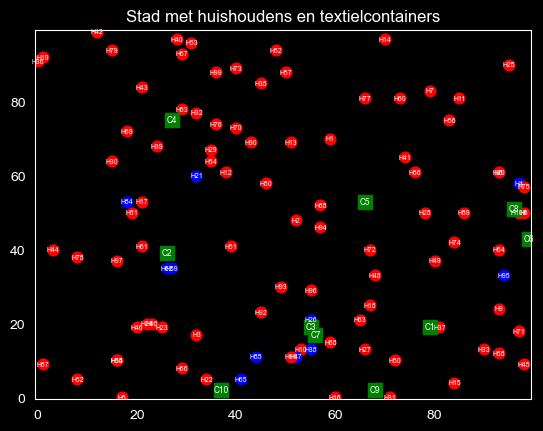


RESULTATEN:

Huishouden   Positie      Buren  Opleiding  Inkomen    Geslacht   Recyclewaarde    Recyclegedrag
--------------------------------------------------------------------------------------------------
H1           (59, 70)     0      laag       laag       vrouw      18.38      15.20        -0.03            False     
H2           (52, 48)     0      midden     midden     vrouw      14.87      19.00        -0.28            False     
H3           (32, 17)     0      laag       midden     man        15.81      19.00        -0.34            False     
H4           (97, 58)     0      midden     hoog       man        7.07       22.80        0.58             True      
H5           (17, 0)      0      midden     hoog       man        20.10      22.80        -0.12            False     
H6           (98, 50)     1      laag       hoog       man        2.24       22.80        0.15             False     
H7           (79, 83)     0      hoog       midden     vrouw      32.70      19.00

In [8]:
## versie 2
# eigenschappen huishouden toegevoegd: opleidingsniveau, inkomen en geslacht
# hoeveelheid textielproductie per huishouden toegevoegd

import random
import math
from mesa import Model, Agent
from mesa.space import MultiGrid
import matplotlib.pyplot as plt


# Agent: huishouden
class Huishouden(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)
        self.recyclewaarde = 0
        self.sociale_gevoeligheid = 0
        self.recyclegedrag = False

        self.opleidingsniveau = random.choice(["laag", "midden", "hoog"])
        self.inkomen = random.choice(["laag", "midden", "hoog"])
        self.geslacht = random.choice(["man", "vrouw"])

        # Basis textielafval is 19 kg
        self.textielafval = 19

        # Pas de hoeveelheid textielafval aan op basis van inkomen
        if self.inkomen == "laag":
            self.textielafval *= 0.8  # Lager inkomen, minder textielafval
        elif self.inkomen == "hoog":
            self.textielafval *= 1.2  # Hoger inkomen, meer textielafval
        # "midden" inkomen hoeft geen aanpassing, dus blijft de basis van 19 kg

# Agent: container
class Container(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)

# Model: stad
class Stad(Model):
    def __init__(self, width=10, height=10, num_people=5, people_per_container=2):
        super().__init__()

        self.grid = MultiGrid(width, height, torus=False)

        self.huishoudens = []
        self.containers = []

        self.id = 0

        # drempelwaarde
        self.drempel = 0.5

        # aantal containers berekenen
        num_containers = math.ceil(num_people / people_per_container)

        # containers plaatsen
        for _ in range(num_containers):
            c = Container(self.next_id(), self)
            self.grid.place_agent(c, (random.randint(0, width - 1), random.randint(0, height - 1)))
            self.containers.append(c)

        # huishoudens plaatsen
        for _ in range(num_people):
            h = Huishouden(self.next_id(), self)
            self.grid.place_agent(h, (random.randint(0, width - 1), random.randint(0, height - 1)))
            self.huishoudens.append(h)

        # recyclegedrag berekenen
        self.bereken_recyclegedrag()

    def next_id(self):
        self.id += 1
        return self.id

    # afstand berekenen
    def euclidische_afstand(self, pos1, pos2):
        return math.sqrt((pos1[0] - pos2[0]) ** 2 + (pos1[1] - pos2[1]) ** 2)

    # dichtstbijzijnde container
    def dichtstbijzijnde_container(self, huishouden):
        beste_container = None
        kleinste_afstand = float("inf")

        for container in self.containers:
            afstand = self.euclidische_afstand(huishouden.pos, container.pos)

            if afstand < kleinste_afstand:
                kleinste_afstand = afstand
                beste_container = container

        return beste_container, kleinste_afstand

    # buren tellen (4 richtingen)
    def tel_buren(self, huishouden):
        x, y = huishouden.pos
        aantal_buren = 0

        buur_posities = [
            (x - 1, y),
            (x + 1, y),
            (x, y - 1),
            (x, y + 1)
        ]

        for bx, by in buur_posities:
            if 0 <= bx < self.grid.width and 0 <= by < self.grid.height:
                inhoud = self.grid.get_cell_list_contents([(bx, by)])

                for agent in inhoud:
                    if isinstance(agent, Huishouden):
                        aantal_buren += 1

        return aantal_buren

    # recyclegedrag bepalen
    def bereken_recyclegedrag(self):
        for huishouden in self.huishoudens:
            # random startwaarde
            huishouden.recyclewaarde = random.random()

            # buren tellen
            huishouden.sociale_gevoeligheid = self.tel_buren(huishouden)
            #afstand tot textielcontainer
            container, afstand = self.dichtstbijzijnde_container(huishouden)
            huishouden.afstand = afstand

            # +0.1 per buur
            huishouden.recyclewaarde += huishouden.sociale_gevoeligheid * 0.05
            # -0.1 per afstandseenheid tot textielcontainer
            huishouden.recyclewaarde -= afstand * 0.025
            # beslissing
            huishouden.recyclegedrag = huishouden.recyclewaarde > self.drempel

    # resultaten weergeven in nette tabel
    def resultaten(self):
        print("\nRESULTATEN:\n")

        print(f"{'Huishouden':<12} {'Positie':<12} {'Buren':<6} {'Opleiding':<10} {'Inkomen':<10} {'Geslacht':<10} {'Recyclewaarde':<16} {'Recyclegedrag':<10}")
        print("-" * 98)

        for i, huishouden in enumerate(self.huishoudens, start=1):
            print(
                f"H{i:<11} "
                f"{str(huishouden.pos):<12} "
                f"{huishouden.sociale_gevoeligheid:<6} "
                f"{huishouden.opleidingsniveau:<10} "
                f"{huishouden.inkomen:<10} "
                f"{huishouden.geslacht:<10} "
                f"{huishouden.afstand:<10.2f} "
                f"{huishouden.textielafval:<12.2f} "
                f"{huishouden.recyclewaarde:<16.2f} "
                f"{str(huishouden.recyclegedrag):<10}"
            )

    # visualisatie: stad met inwoners en textielcontainers
    def visualiseer(self):
        for i, h in enumerate(self.huishoudens, start=1):
            x, y = h.pos
            kleur = "blue" if h.recyclegedrag else "red"
            plt.scatter(x, y, color=kleur, s=60)
            plt.text(x, y, f"H{i}", fontsize=5, ha="center", va="center")

        for i, c in enumerate(self.containers, start=1):
            x, y = c.pos
            plt.scatter(x, y, color="green", s=100, marker="s")
            plt.text(x, y, f"C{i}", fontsize=6, ha="center", va="center")

        plt.grid()
        plt.title("Stad met huishoudens en textielcontainers")
        plt.xlim(-0.5, self.grid.width - 0.5)
        plt.ylim(-0.5, self.grid.height - 0.5)
        plt.show()

# model runnen
model = Stad(width=100, height=100, num_people=100, people_per_container=10)
model.visualiseer()
model.resultaten()

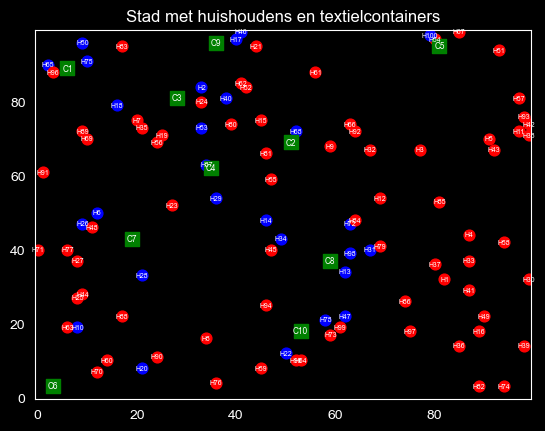


RESULTATEN:

Huishouden   Positie      Buren  Opleiding  Inkomen    Geslacht   Afstand    Textielafval Recyclewaarde    Recyclegedrag
------------------------------------------------------------------------------------------------------------------------
H1           (82, 32)     0      hoog       hoog       man        23.54      20.52        0.30             False     
H2           (33, 84)     0      hoog       midden     vrouw      5.83       20.90        0.74             True      
H3           (77, 67)     0      midden     midden     man        26.08      17.10        0.06             False     
H4           (87, 44)     0      laag       hoog       vrouw      28.86      25.08        0.26             False     
H5           (91, 70)     0      hoog       hoog       vrouw      26.93      25.08        0.46             False     
H6           (12, 50)     0      hoog       hoog       vrouw      9.90       25.08        0.82             True      
H7           (20, 75)     0      laa

In [23]:
## versie 3
# effecten van opleidingsniveau en geslacht meenemen in de recyclewaarde van een huishouden
# effect geslacht meenemen in hoeveelheid textielafval

import random
import math
from mesa import Model, Agent
from mesa.space import MultiGrid
import matplotlib.pyplot as plt


# Agent: huishouden
class Huishouden(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)
        self.recyclewaarde = 0
        self.sociale_gevoeligheid = 0
        self.recyclegedrag = False

        self.opleidingsniveau = random.choice(["laag", "midden", "hoog"])
        self.inkomen = random.choice(["laag", "midden", "hoog"])
        self.geslacht = random.choice(["man", "vrouw"])

        # Basis textielafval is 19 kg
        self.textielafval = 19

        # Correctie hoeveelheid textielafval obv. inkomen
        if self.inkomen == "laag":
            self.textielafval *= 0.8  #Lager inkomen, minder textielafval
        elif self.inkomen == "hoog":
            self.textielafval *= 1.2  #Hoger inkomen, meer textielafval
        #"midden" inkomen hoeft geen aanpassing, dus blijft 19 kg

        # Correctie hoeveelheid textielafval obv. geslacht
        if self.geslacht == "man":
            self.textielafval *= 0.9  # Mannen hebben minder textielafval
        elif self.geslacht == "vrouw":
            self.textielafval *= 1.1  # Vrouwen hebben meer textielafval

# Agent: container
class Container(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)

# Model: stad
class Stad(Model):
    def __init__(self, width=10, height=10, num_people=5, people_per_container=2):
        super().__init__()

        self.grid = MultiGrid(width, height, torus=False)

        self.huishoudens = []
        self.containers = []

        self.id = 0

        # drempelwaarde
        self.drempel = 0.5

        # aantal containers berekenen
        num_containers = math.ceil(num_people / people_per_container)

        # containers plaatsen
        for _ in range(num_containers):
            c = Container(self.next_id(), self)
            self.grid.place_agent(c, (random.randint(0, width - 1), random.randint(0, height - 1)))
            self.containers.append(c)

        # huishoudens plaatsen
        for _ in range(num_people):
            h = Huishouden(self.next_id(), self)
            self.grid.place_agent(h, (random.randint(0, width - 1), random.randint(0, height - 1)))
            self.huishoudens.append(h)

        # recyclegedrag berekenen
        self.bereken_recyclegedrag()

    def next_id(self):
        self.id += 1
        return self.id

    # afstand berekenen
    def euclidische_afstand(self, pos1, pos2):
        return math.sqrt((pos1[0] - pos2[0]) ** 2 + (pos1[1] - pos2[1]) ** 2)

    # dichtstbijzijnde container
    def dichtstbijzijnde_container(self, huishouden):
        beste_container = None
        kleinste_afstand = float("inf")

        for container in self.containers:
            afstand = self.euclidische_afstand(huishouden.pos, container.pos)

            if afstand < kleinste_afstand:
                kleinste_afstand = afstand
                beste_container = container

        return beste_container, kleinste_afstand

    # buren tellen (4 richtingen)
    def tel_buren(self, huishouden):
        x, y = huishouden.pos
        aantal_buren = 0

        buur_posities = [
            (x - 1, y),
            (x + 1, y),
            (x, y - 1),
            (x, y + 1)
        ]

        for bx, by in buur_posities:
            if 0 <= bx < self.grid.width and 0 <= by < self.grid.height:
                inhoud = self.grid.get_cell_list_contents([(bx, by)])

                for agent in inhoud:
                    if isinstance(agent, Huishouden):
                        aantal_buren += 1

        return aantal_buren

    # recyclegedrag bepalen
    def bereken_recyclegedrag(self):
        for huishouden in self.huishoudens:
            # random startwaarde
            huishouden.recyclewaarde = random.random()

            # buren tellen
            huishouden.sociale_gevoeligheid = self.tel_buren(huishouden)
            #afstand tot textielcontainer
            container, afstand = self.dichtstbijzijnde_container(huishouden)
            huishouden.afstand = afstand

            # +0.1 per buur
            huishouden.recyclewaarde += huishouden.sociale_gevoeligheid * 0.05
            # -0.1 per afstandseenheid tot textielcontainer
            huishouden.recyclewaarde -= afstand * 0.025

            # invloed inkomen op recyclewaarde (hoger inkomen -> meer milieubewust)
            if huishouden.inkomen == "hoog":
                huishouden.recyclewaarde += 0.1
            elif huishouden.inkomen == "laag":
                huishouden.recyclewaarde -= 0.1

            # invloed geslacht op recyclewaarde (vrouwen meer milieubewust dan mannen)
            if huishouden.geslacht == "vrouw":
                huishouden.recyclewaarde += 0.05
            elif huishouden.geslacht == "man":
                huishouden.recyclewaarde -= 0.05

            # beslissing
            huishouden.recyclegedrag = huishouden.recyclewaarde > self.drempel

    # resultaten weergeven in nette tabel
    def resultaten(self):
        print("\nRESULTATEN:\n")

        print(f"{'Huishouden':<12} {'Positie':<12} {'Buren':<6} {'Opleiding':<10} {'Inkomen':<10} {'Geslacht':<10} {'Afstand':<10} {'Textielafval':<12} {'Recyclewaarde':<16} {'Recyclegedrag':<10}")
        print("-" * 120)

        for i, huishouden in enumerate(self.huishoudens, start=1):
            print(
                f"H{i:<11} "
                f"{str(huishouden.pos):<12} "
                f"{huishouden.sociale_gevoeligheid:<6} "
                f"{huishouden.opleidingsniveau:<10} "
                f"{huishouden.inkomen:<10} "
                f"{huishouden.geslacht:<10} "
                f"{huishouden.afstand:<10.2f} "
                f"{huishouden.textielafval:<12.2f} "
                f"{huishouden.recyclewaarde:<16.2f} "
                f"{str(huishouden.recyclegedrag):<10}"
            )

    # visualisatie: stad met inwoners en textielcontainers
    def visualiseer(self):
        for i, h in enumerate(self.huishoudens, start=1):
            x, y = h.pos
            kleur = "blue" if h.recyclegedrag else "red"
            plt.scatter(x, y, color=kleur, s=60)
            plt.text(x, y, f"H{i}", fontsize=5, ha="center", va="center")

        for i, c in enumerate(self.containers, start=1):
            x, y = c.pos
            plt.scatter(x, y, color="green", s=100, marker="s")
            plt.text(x, y, f"C{i}", fontsize=6, ha="center", va="center")

        plt.grid()
        plt.title("Stad met huishoudens en textielcontainers")
        plt.xlim(-0.5, self.grid.width - 0.5)
        plt.ylim(-0.5, self.grid.height - 0.5)
        plt.show()

# model runnen
model = Stad(width=100, height=100, num_people=100, people_per_container=10)
model.visualiseer()
model.resultaten()


WEEK 1


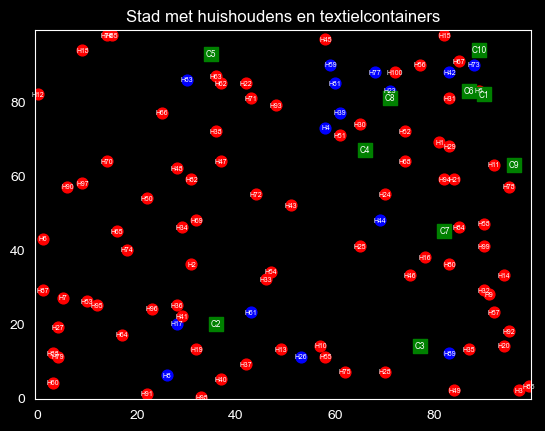


RESULTATEN:

Huishouden   Positie      Buren  Opleiding  Inkomen    Geslacht   Afstand    Textielafval Recyclewaarde    Recyclegedrag
------------------------------------------------------------------------------------------------------------------------
H1           (81, 69)     0      hoog       laag       man        15.13      13.68        -0.27            False     
H2           (31, 36)     0      laag       midden     man        16.76      17.10        -0.31            False     
H3           (97, 2)      0      hoog       hoog       vrouw      23.32      25.08        0.48             False     
H4           (58, 73)     0      hoog       midden     vrouw      10.00      20.90        0.54             True      
H5           (89, 83)     0      midden     midden     man        1.41       17.10        0.31             False     
H6           (1, 43)      0      midden     midden     vrouw      41.88      20.90        -0.10            False     
H7           (5, 27)      0      hoo

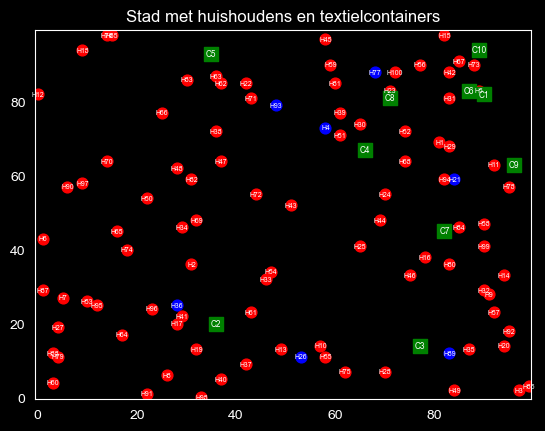


RESULTATEN:

Huishouden   Positie      Buren  Opleiding  Inkomen    Geslacht   Afstand    Textielafval Recyclewaarde    Recyclegedrag
------------------------------------------------------------------------------------------------------------------------
H1           (81, 69)     0      hoog       laag       man        15.13      13.68        -0.03            False     
H2           (31, 36)     0      laag       midden     man        16.76      17.10        0.22             False     
H3           (97, 2)      0      hoog       hoog       vrouw      23.32      25.08        -0.32            False     
H4           (58, 73)     0      hoog       midden     vrouw      10.00      20.90        0.79             True      
H5           (89, 83)     0      midden     midden     man        1.41       17.10        0.41             False     
H6           (1, 43)      0      midden     midden     vrouw      41.88      20.90        -0.95            False     
H7           (5, 27)      0      hoo

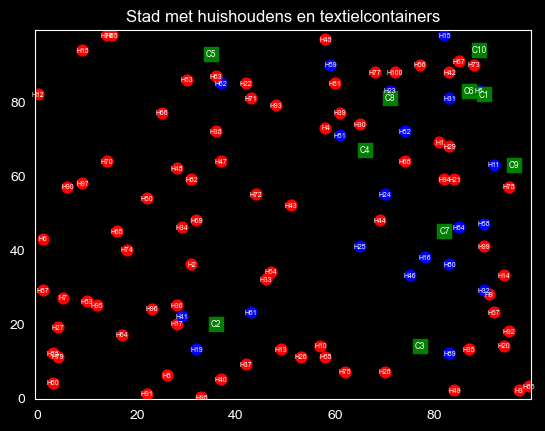


RESULTATEN:

Huishouden   Positie      Buren  Opleiding  Inkomen    Geslacht   Afstand    Textielafval Recyclewaarde    Recyclegedrag
------------------------------------------------------------------------------------------------------------------------
H1           (81, 69)     0      hoog       laag       man        15.13      13.68        0.28             False     
H2           (31, 36)     0      laag       midden     man        16.76      17.10        0.27             False     
H3           (97, 2)      0      hoog       hoog       vrouw      23.32      25.08        0.15             False     
H4           (58, 73)     0      hoog       midden     vrouw      10.00      20.90        0.48             False     
H5           (89, 83)     0      midden     midden     man        1.41       17.10        0.73             True      
H6           (1, 43)      0      midden     midden     vrouw      41.88      20.90        -0.82            False     
H7           (5, 27)      0      hoo

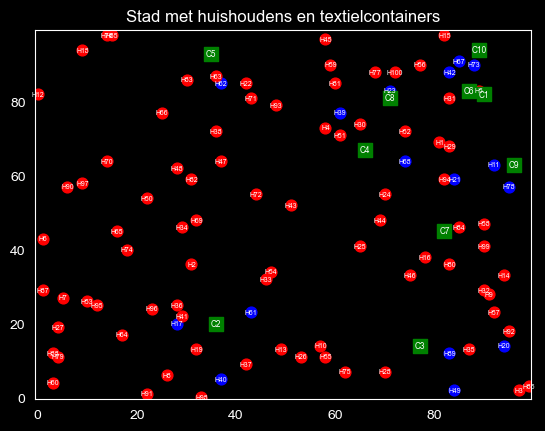


RESULTATEN:

Huishouden   Positie      Buren  Opleiding  Inkomen    Geslacht   Afstand    Textielafval Recyclewaarde    Recyclegedrag
------------------------------------------------------------------------------------------------------------------------
H1           (81, 69)     0      hoog       laag       man        15.13      13.68        -0.50            False     
H2           (31, 36)     0      laag       midden     man        16.76      17.10        -0.32            False     
H3           (97, 2)      0      hoog       hoog       vrouw      23.32      25.08        0.44             False     
H4           (58, 73)     0      hoog       midden     vrouw      10.00      20.90        0.50             False     
H5           (89, 83)     0      midden     midden     man        1.41       17.10        0.47             False     
H6           (1, 43)      0      midden     midden     vrouw      41.88      20.90        -0.39            False     
H7           (5, 27)      0      hoo

In [4]:
## laatste versie (versie 4)
# eigenschappen textielcontainer toegevoegd: capaciteit, vulgraad, ledigingfrequentie
# stap functie toegevoegd (maar klopt nog niet helemaal)
# later nog toevoegen: textiel uberhaupt wel of niet weggooien (hoe vaak gooi je textiel weg?)
# later juiste waardes gebruiken voor invloed van bepaalde eigenschappen + juiste verhoudingen man/vrouw, inkomens, opleiding, aantal inwoners, aantal containers, etc.


import random
import math
from mesa import Model, Agent
from mesa.space import MultiGrid
import matplotlib.pyplot as plt


# Agent: huishouden
class Huishouden(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)
        self.recyclewaarde = 0
        self.sociale_gevoeligheid = 0
        self.recyclegedrag = False

        self.opleidingsniveau = random.choice(["laag", "midden", "hoog"])
        self.inkomen = random.choice(["laag", "midden", "hoog"])
        self.geslacht = random.choice(["man", "vrouw"])

        # Basis textielafval is 19 kg
        self.textielafval = 19

        # Correctie hoeveelheid textielafval obv. inkomen
        if self.inkomen == "laag":
            self.textielafval *= 0.8  #Lager inkomen, minder textielafval
        elif self.inkomen == "hoog":
            self.textielafval *= 1.2  #Hoger inkomen, meer textielafval
        #"midden" inkomen hoeft geen aanpassing, dus blijft 19 kg

        # Correctie hoeveelheid textielafval obv. geslacht
        if self.geslacht == "man":
            self.textielafval *= 0.9  # Mannen hebben minder textielafval
        elif self.geslacht == "vrouw":
            self.textielafval *= 1.1  # Vrouwen hebben meer textielafval

# Agent: textielcontainer
class Container(Agent):
    def __init__(self, unique_id, model):
        super().__init__(unique_id, model)


        self.capaciteit = 1250  # in kg (5 m³ * 250 kg/m³)
        self.vulgraad = 0  # Hoe vol is de container?
        self.ledigingsfrequentie = 1  # Lediging 1 keer per week

    # Container ledigen (reset de vulgraad naar 0)
    def ledigen(self):
        self.vulgraad = 0

# Model: stad
class Stad(Model):
    def __init__(self, width=10, height=10, num_people=5, people_per_container=2):
        super().__init__()

        self.grid = MultiGrid(width, height, torus=False)

        self.huishoudens = []
        self.containers = []

        self.id = 0

        # drempelwaarde
        self.drempel = 0.5

        # aantal containers berekenen
        num_containers = math.ceil(num_people / people_per_container)

        # containers plaatsen
        for _ in range(num_containers):
            c = Container(self.next_id(), self)
            self.grid.place_agent(c, (random.randint(0, width - 1), random.randint(0, height - 1)))
            self.containers.append(c)

        # huishoudens plaatsen
        for _ in range(num_people):
            h = Huishouden(self.next_id(), self)
            self.grid.place_agent(h, (random.randint(0, width - 1), random.randint(0, height - 1)))
            self.huishoudens.append(h)

        # recyclegedrag berekenen
        self.bereken_recyclegedrag()

    def next_id(self):
        self.id += 1
        return self.id

    # afstand berekenen
    def euclidische_afstand(self, pos1, pos2):
        return math.sqrt((pos1[0] - pos2[0]) ** 2 + (pos1[1] - pos2[1]) ** 2)

    # dichtstbijzijnde container
    def dichtstbijzijnde_container(self, huishouden):
        beste_container = None
        kleinste_afstand = float("inf")

        for container in self.containers:
            afstand = self.euclidische_afstand(huishouden.pos, container.pos)

            if afstand < kleinste_afstand:
                kleinste_afstand = afstand
                beste_container = container

        return beste_container, kleinste_afstand

    # buren tellen (4 richtingen)
    def tel_buren(self, huishouden):
        x, y = huishouden.pos
        aantal_buren = 0

        buur_posities = [
            (x - 1, y),
            (x + 1, y),
            (x, y - 1),
            (x, y + 1)
        ]

        for bx, by in buur_posities:
            if 0 <= bx < self.grid.width and 0 <= by < self.grid.height:
                inhoud = self.grid.get_cell_list_contents([(bx, by)])

                for agent in inhoud:
                    if isinstance(agent, Huishouden):
                        aantal_buren += 1

        return aantal_buren

    # recyclegedrag bepalen
    def bereken_recyclegedrag(self):
        for huishouden in self.huishoudens:
            # random startwaarde
            huishouden.recyclewaarde = random.random()

            # buren tellen
            huishouden.sociale_gevoeligheid = self.tel_buren(huishouden)
            #afstand tot textielcontainer
            container, afstand = self.dichtstbijzijnde_container(huishouden)
            huishouden.afstand = afstand

            # +0.1 per buur
            huishouden.recyclewaarde += huishouden.sociale_gevoeligheid * 0.05
            # -0.1 per afstandseenheid tot textielcontainer
            huishouden.recyclewaarde -= afstand * 0.025

            # invloed inkomen op recyclewaarde (hoger inkomen -> meer milieubewust)
            if huishouden.inkomen == "hoog":
                huishouden.recyclewaarde += 0.1
            elif huishouden.inkomen == "laag":
                huishouden.recyclewaarde -= 0.1

            # invloed geslacht op recyclewaarde (vrouwen meer milieubewust dan mannen)
            if huishouden.geslacht == "vrouw":
                huishouden.recyclewaarde += 0.05
            elif huishouden.geslacht == "man":
                huishouden.recyclewaarde -= 0.05

            # beslissing
            huishouden.recyclegedrag = huishouden.recyclewaarde > self.drempel

            # Huishouden recyclet het textielafval -> textielafval toevoegen aan vulgraad van de container
            if huishouden.recyclegedrag:
                # Geen overvolle container
                if container.vulgraad + huishouden.textielafval <= container.capaciteit:
                    container.vulgraad += huishouden.textielafval
                else:
                    # Als de container vol is, voeg alleen zo veel mogelijk textielafval toe en het resterende textielafval gaat bij het restafval
                    container.vulgraad = container.capaciteit

    # Simulatie van de tijd (om de containers te legen na elke week)
    def stap(self):
        # Simuleer het recyclegedrag van huishoudens
        self.bereken_recyclegedrag()

        # Ledig de containers (na elke week)
        for container in self.containers:
            container.ledigen()

    # resultaten weergeven in nette tabel
    def resultaten(self):
        print("\nRESULTATEN:\n")

        print(f"{'Huishouden':<12} {'Positie':<12} {'Buren':<6} {'Opleiding':<10} {'Inkomen':<10} {'Geslacht':<10} {'Afstand':<10} {'Textielafval':<12} {'Recyclewaarde':<16} {'Recyclegedrag':<10}")
        print("-" * 120)

        for i, huishouden in enumerate(self.huishoudens, start=1):
            print(
                f"H{i:<11} "
                f"{str(huishouden.pos):<12} "
                f"{huishouden.sociale_gevoeligheid:<6} "
                f"{huishouden.opleidingsniveau:<10} "
                f"{huishouden.inkomen:<10} "
                f"{huishouden.geslacht:<10} "
                f"{huishouden.afstand:<10.2f} "
                f"{huishouden.textielafval:<12.2f} "
                f"{huishouden.recyclewaarde:<16.2f} "
                f"{str(huishouden.recyclegedrag):<10}"
            )

    # visualisatie: stad met inwoners en textielcontainers
    def visualiseer(self):
        for i, h in enumerate(self.huishoudens, start=1):
            x, y = h.pos
            kleur = "blue" if h.recyclegedrag else "red"
            plt.scatter(x, y, color=kleur, s=60)
            plt.text(x, y, f"H{i}", fontsize=5, ha="center", va="center")

        for i, c in enumerate(self.containers, start=1):
            x, y = c.pos
            plt.scatter(x, y, color="green", s=100, marker="s")
            plt.text(x, y, f"C{i}", fontsize=6, ha="center", va="center")

        plt.grid()
        plt.title("Stad met huishoudens en textielcontainers")
        plt.xlim(-0.5, self.grid.width - 0.5)
        plt.ylim(-0.5, self.grid.height - 0.5)
        plt.show()

# model
model = Stad(width=100, height=100, num_people=100, people_per_container=10)

# Simuleer 10 weken (10 stappen)
for week in range(4):
    print(f"\nWEEK {week + 1}")
    model.stap()
    model.visualiseer()
    model.resultaten()